✅ Bibliotecas carregadas com sucesso!
   GeoPandas versão: 1.1.2
⏳ Baixando shapefile dos estados brasileiros do IBGE...
✅ Shapefile carregado! Total de unidades: 27
   Colunas disponíveis: ['CD_UF', 'NM_UF', 'SIGLA_UF', 'NM_REGIAO', 'AREA_KM2', 'geometry']
  SIGLA_UF      NM_UF NM_REGIAO
0       AC       Acre     Norte
1       AM   Amazonas     Norte
2       PA       Pará     Norte
3       AP      Amapá     Norte
4       TO  Tocantins     Norte
✅ Dados temáticos integrados ao shapefile!
   SIGLA_UF    IDH  Cobertura_Vegetal_pct        Regiao
17       SP  0.826                   13.2       Sudeste
24       DF  0.824                    2.1  Centro-Oeste
18       PR  0.796                   25.4           Sul
16       RJ  0.796                   19.8       Sudeste
19       SC  0.792                   28.1           Sul
20       RS  0.787                   22.7           Sul
14       MG  0.770                   35.2       Sudeste
21       MS  0.769                   48.9  Centro-Oeste


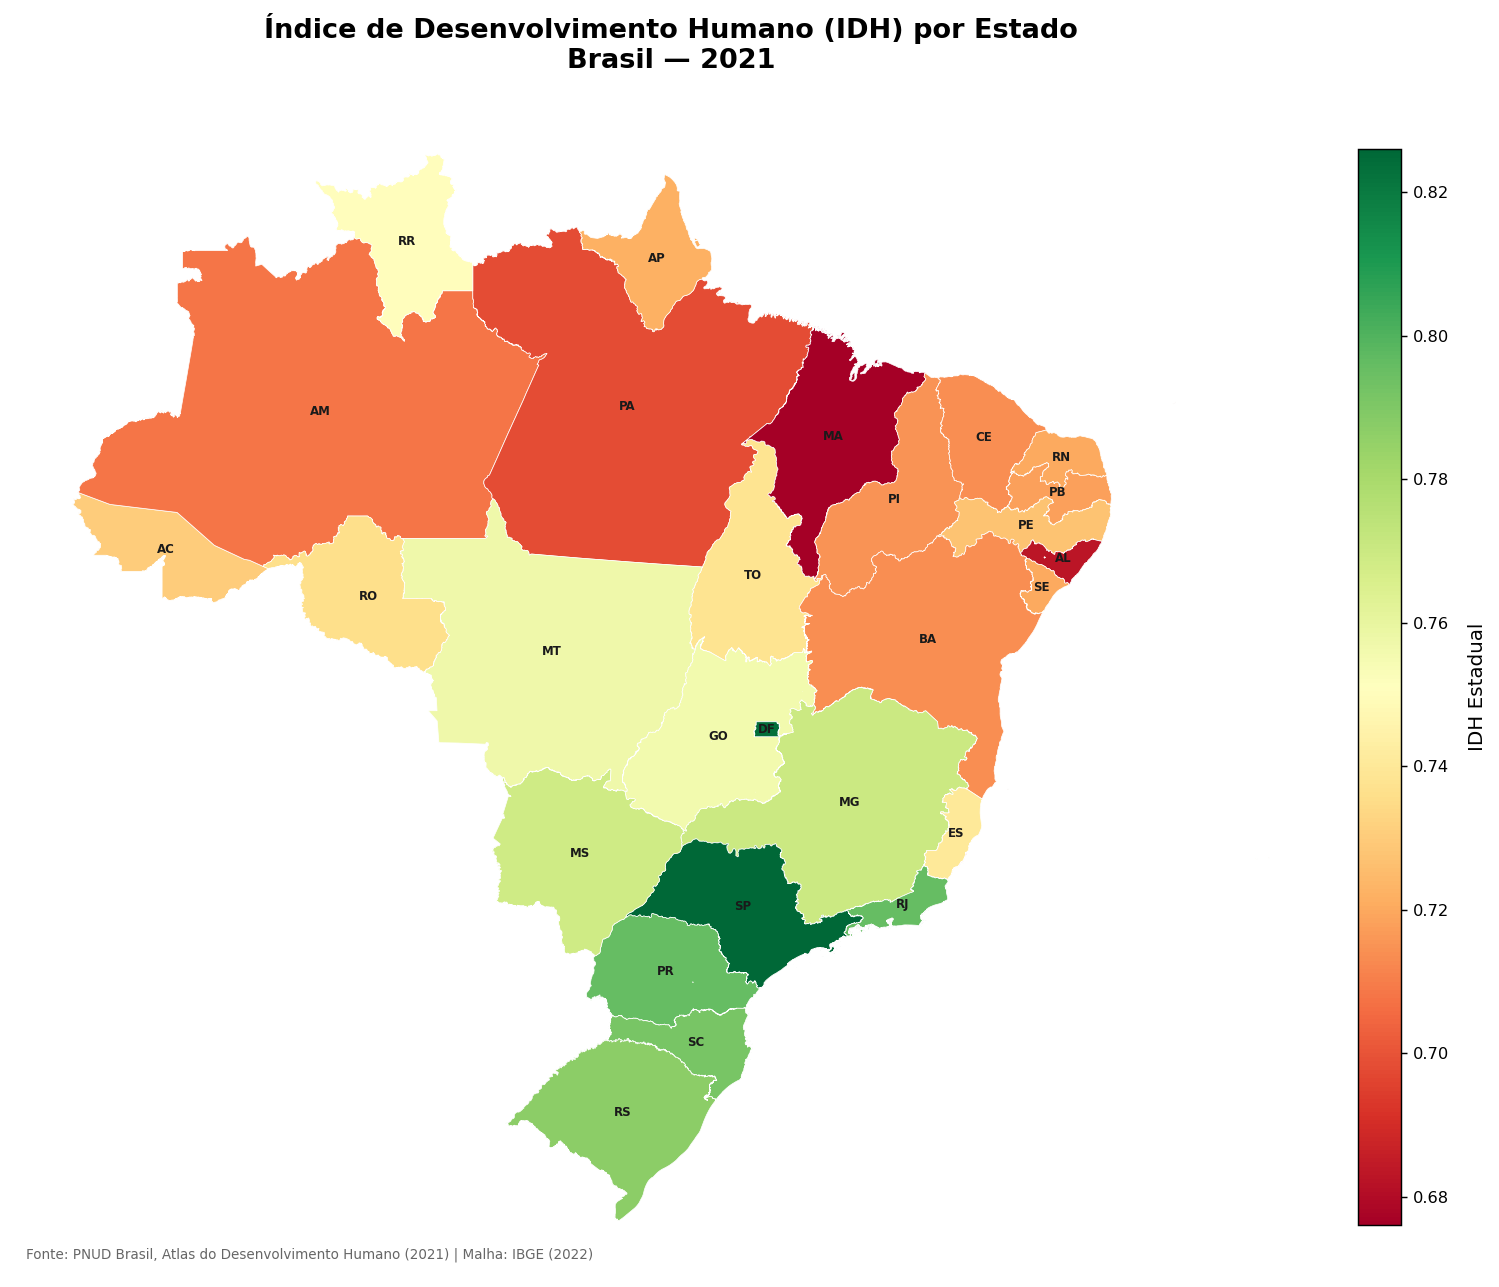

✅ Mapa 1 salvo como 'mapa1_idh_estados.png'


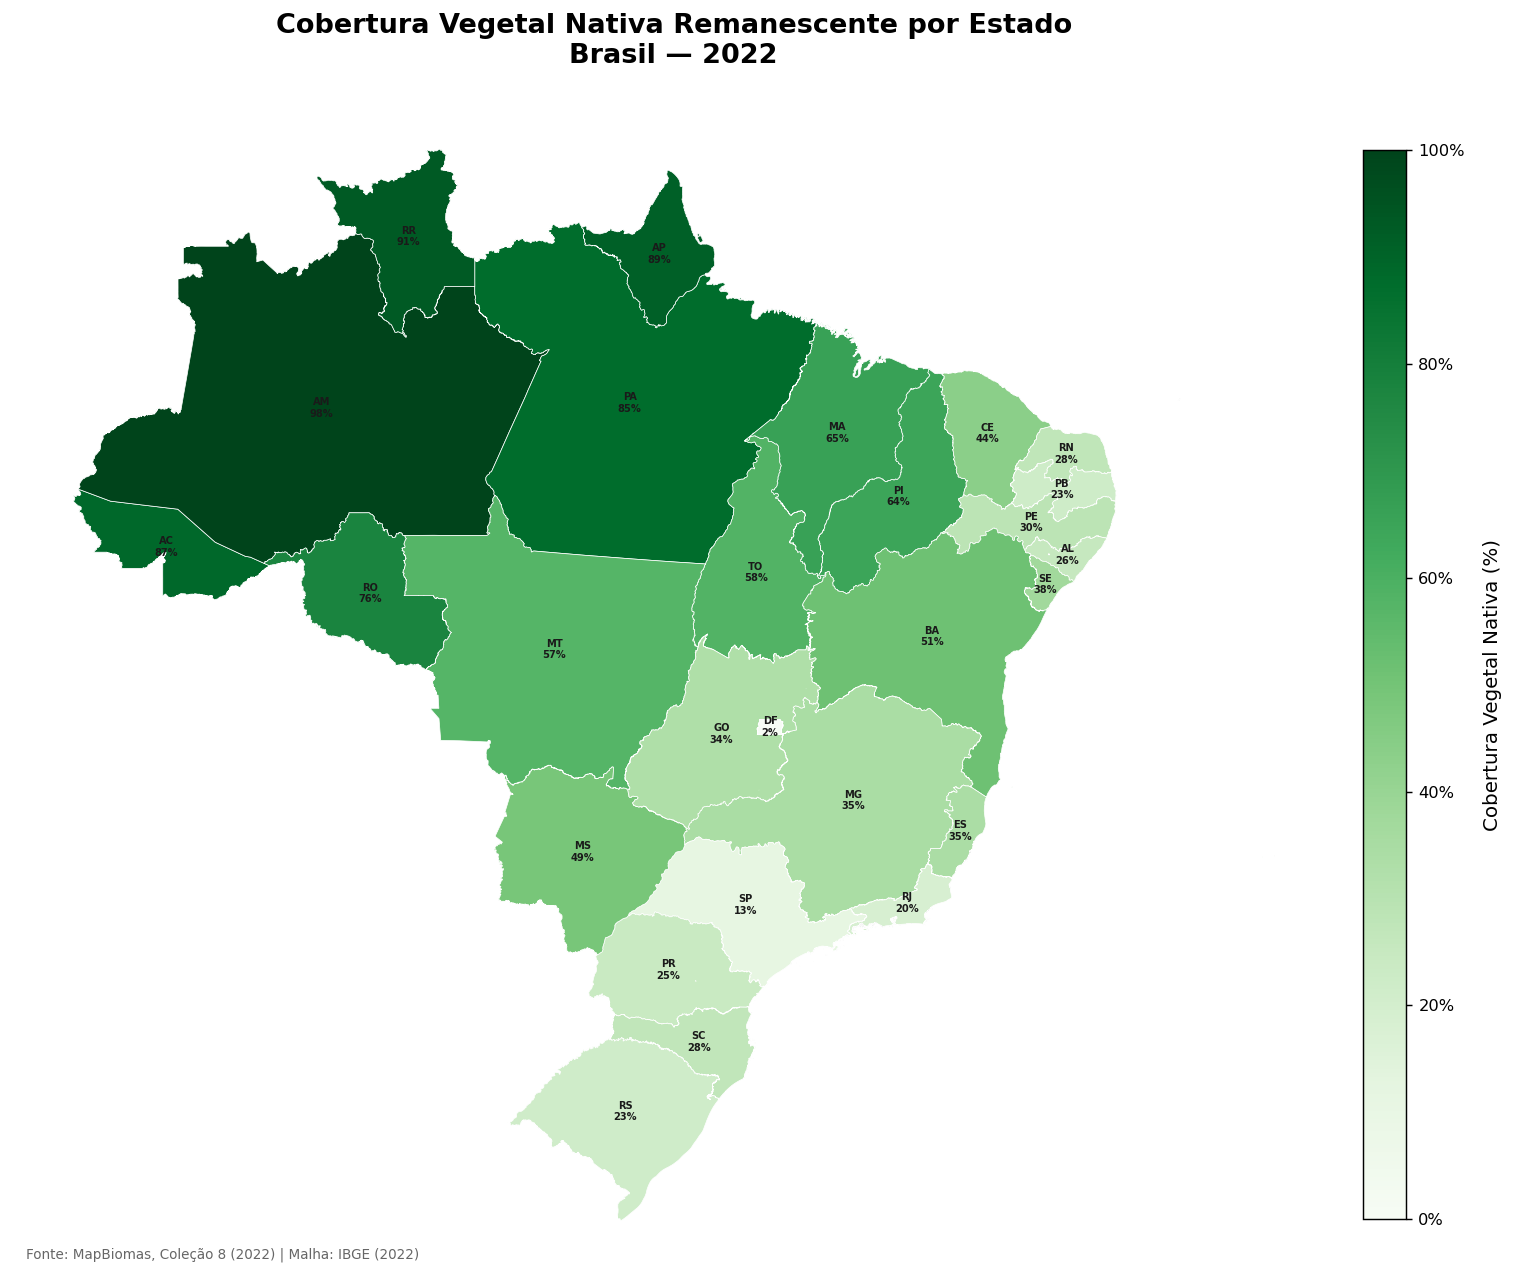

✅ Mapa 2 salvo como 'mapa2_cobertura_vegetal.png'


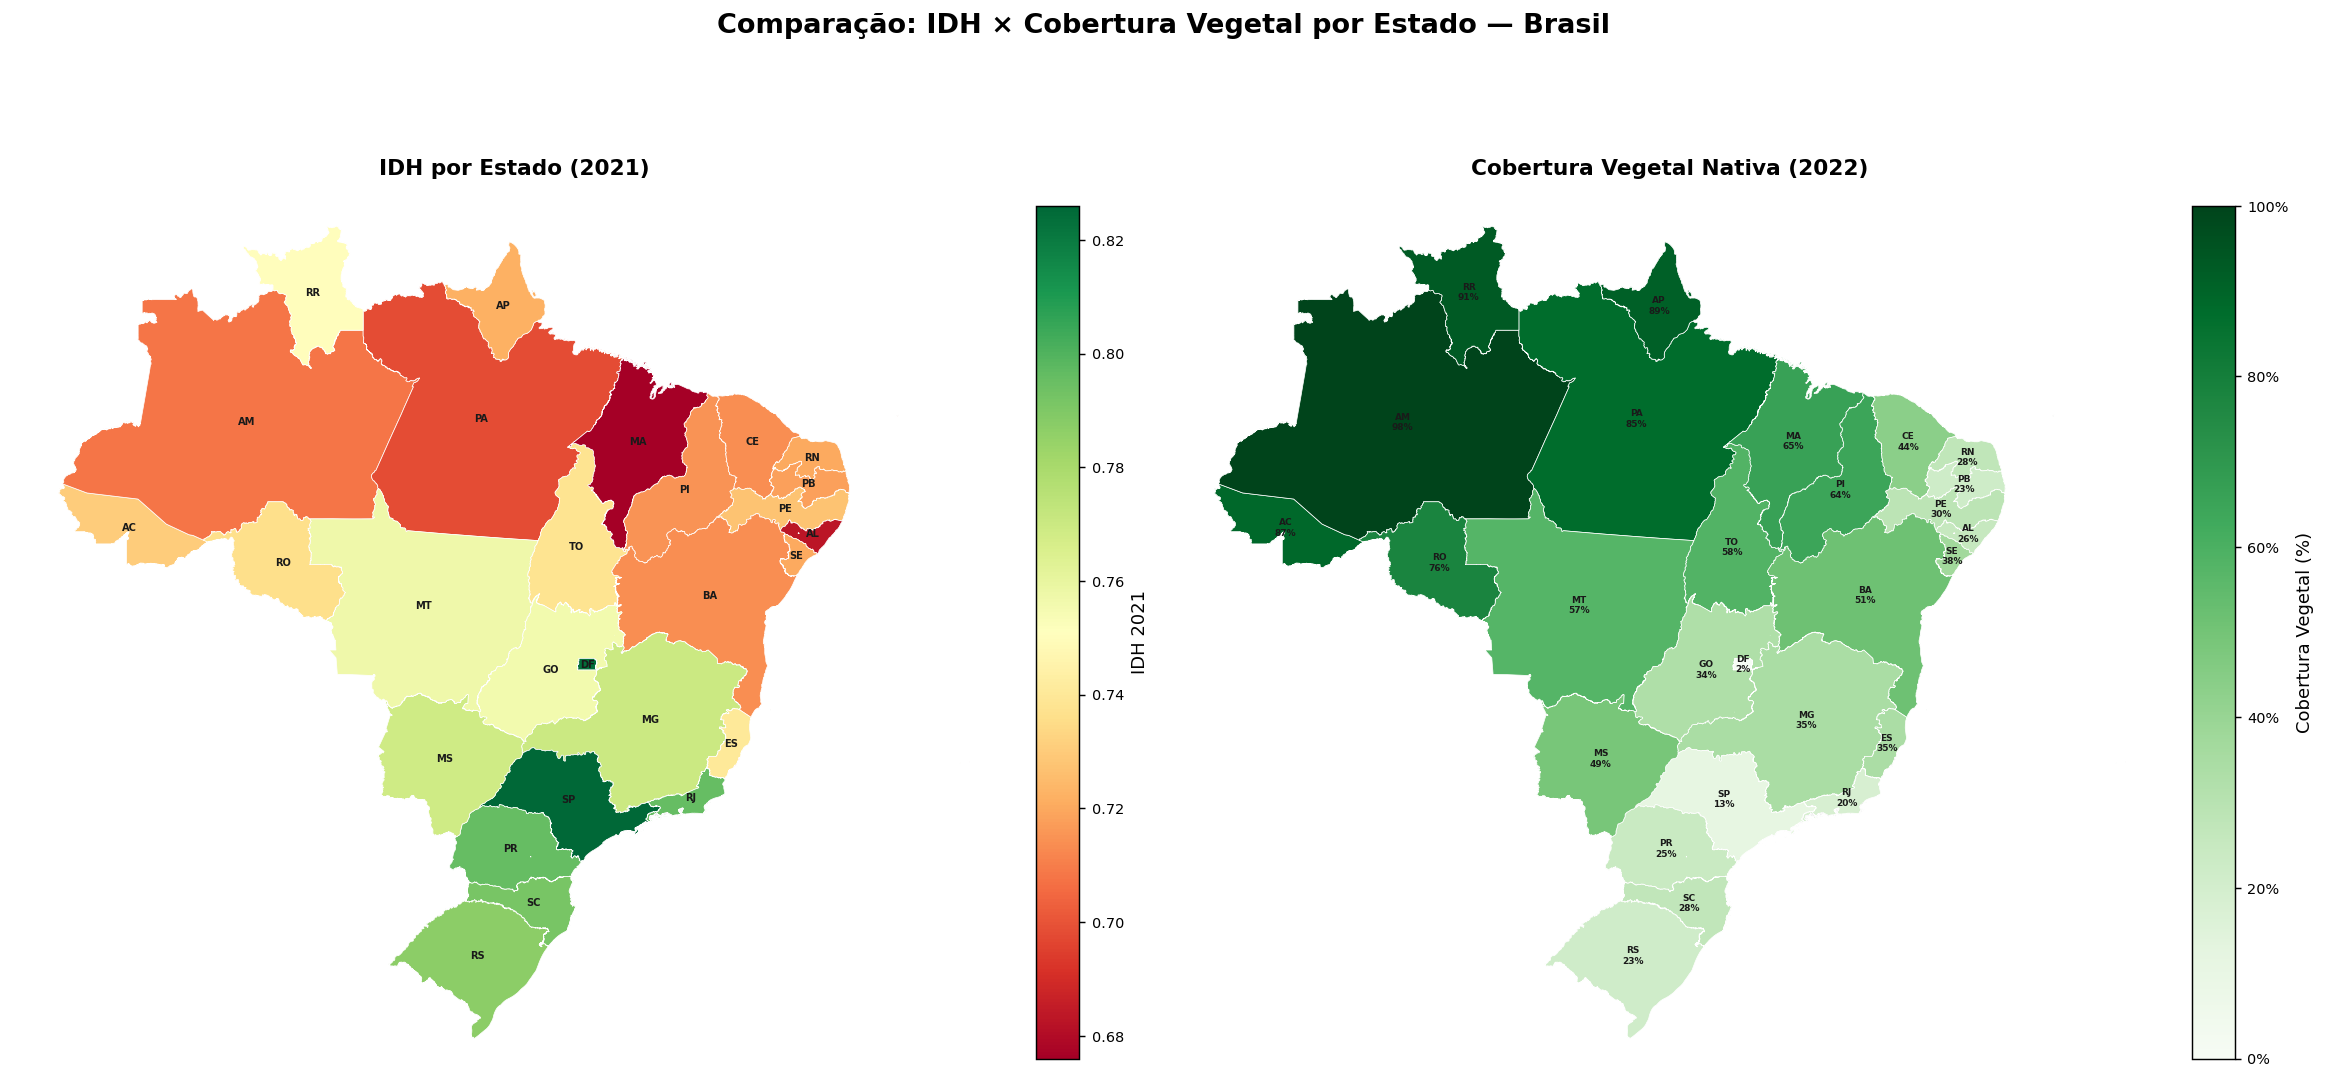

✅ Mapa 3 salvo como 'mapa3_comparacao_idh_vegetal.png'
  ANÁLISE POR REGIÃO GEOGRÁFICA
              IDH Médio  Cobertura Vegetal Média (%)
Regiao                                              
Sul               0.792                       25.400
Sudeste           0.783                       25.725
Centro-Oeste      0.776                       35.475
Norte             0.726                       83.543
Nordeste          0.710                       41.067

  DESTAQUES NACIONAIS

🏆 Maior IDH:            São Paulo (SP) — 0.826
📉 Menor IDH:            Maranhão (MA) — 0.676
🌿 Maior cobertura veg.: Amazonas (AM) — 97.6%
🏭 Menor cobertura veg.: Distrito Federal (DF) — 2.1%

📐 Correlação IDH × Cobertura Vegetal: -0.543
   → Correlação negativa: estados com maior IDH tendem a ter menos vegetação nativa.
   → Isso pode refletir maior urbanização e desmatamento histórico nas regiões mais desenvolvidas.

  PERGUNTAS PARA DEBATE EM SALA DE AULA

1. O mapa do IDH confirma a ideia de que o Brasil tem 

In [2]:
# =============================================================================
# ATIVIDADE DIDÁTICA: "TRAÇANDO O BRASIL"
# Mapas temáticos com GeoPandas — IDH e Cobertura Vegetal por Estado
# Ensino de Geografia com Python — Licenciatura em Geografia
# =============================================================================
# COMO RODAR NO GOOGLE COLAB:
#   1. Acesse https://colab.research.google.com
#   2. Clique em "Novo notebook"
#   3. Cole este código célula por célula (separadas pelos blocos # ── CÉLULA)
#   4. Execute cada célula com Shift+Enter ou clicando no botão ▶
#   O Colab já tem geopandas, pandas e matplotlib — nada para instalar!
# =============================================================================

# -----------------------------------------------------------------------------
# CÉLULA 1 — Instalação e importação das bibliotecas
# -----------------------------------------------------------------------------
# No Colab, o geopandas normalmente já está disponível.
# Caso apareça erro de importação, descomente a linha de instalação abaixo.

# !pip install geopandas --quiet

import geopandas as gpd       # leitura e manipulação de dados geoespaciais
import pandas as pd            # manipulação de tabelas
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Bibliotecas carregadas com sucesso!")
print(f"   GeoPandas versão: {gpd.__version__}")

# -----------------------------------------------------------------------------
# CÉLULA 2 — Download do shapefile dos estados brasileiros (IBGE)
# -----------------------------------------------------------------------------
# O IBGE disponibiliza gratuitamente os shapefiles do Brasil.
# Usamos a URL direta do repositório oficial do IBGE (IBGE Malhas, 2022).
# O GeoPandas consegue ler o arquivo compactado (.zip) diretamente da URL,
# sem precisar baixar e descompactar manualmente.

print("⏳ Baixando shapefile dos estados brasileiros do IBGE...")

url_ibge = (
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/"
    "malhas_territoriais/malhas_municipais/municipio_2022/"
    "Brasil/BR/BR_UF_2022.zip"
)

# Leitura direta do shapefile compactado — o geopandas faz tudo automaticamente
brasil = gpd.read_file(url_ibge)

# Verificação: quantos estados foram carregados?
print(f"✅ Shapefile carregado! Total de unidades: {len(brasil)}")
print(f"   Colunas disponíveis: {list(brasil.columns)}")
print(brasil[['SIGLA_UF', 'NM_UF', 'NM_REGIAO']].head())

# -----------------------------------------------------------------------------
# CÉLULA 3 — Dados temáticos: IDH e Cobertura Vegetal por estado
# -----------------------------------------------------------------------------
# Dados do IDH estadual: PNUD Brasil — Atlas do Desenvolvimento Humano, 2021
# Fonte: https://www.undp.org/pt/brazil/publicacoes/atlas-do-desenvolvimento-humano-no-brasil
#
# Dados de cobertura vegetal nativa: MapBiomas, Coleção 8 (2022)
# Fonte: https://mapbiomas.org/estatisticas

dados_estados = {
    'SIGLA_UF': [
        'AC','AL','AM','AP','BA','CE','DF','ES','GO','MA',
        'MG','MS','MT','PA','PB','PE','PI','PR','RJ','RN',
        'RO','RR','RS','SC','SE','SP','TO'
    ],
    # IDH estadual 2021 (PNUD)
    'IDH': [
        0.730, 0.683, 0.708, 0.722, 0.714, 0.714, 0.824, 0.740, 0.756, 0.676,
        0.770, 0.769, 0.757, 0.698, 0.718, 0.727, 0.715, 0.796, 0.796, 0.720,
        0.736, 0.750, 0.787, 0.792, 0.720, 0.826, 0.738
    ],
    # Cobertura vegetal nativa remanescente (% do território do estado) — MapBiomas 2022
    'Cobertura_Vegetal_pct': [
        87.1, 26.4, 97.6, 89.3, 51.2, 43.8,  2.1, 34.7, 33.6, 65.4,
        35.2, 48.9, 57.3, 85.4, 23.1, 29.7, 63.8, 25.4, 19.8, 28.3,
        76.4, 91.2, 22.7, 28.1, 37.9, 13.2, 57.8
    ],
    # Região geográfica (para análise comparativa)
    'Regiao': [
        'Norte','Nordeste','Norte','Norte','Nordeste','Nordeste',
        'Centro-Oeste','Sudeste','Centro-Oeste','Nordeste',
        'Sudeste','Centro-Oeste','Centro-Oeste','Norte','Nordeste',
        'Nordeste','Nordeste','Sul','Sudeste','Nordeste',
        'Norte','Norte','Sul','Sul','Nordeste','Sudeste','Norte'
    ]
}

df = pd.DataFrame(dados_estados)

# Unimos os dados temáticos ao shapefile pelo código da UF
# O merge é como um "procv" do Excel — une as tabelas pela coluna em comum
brasil = brasil.merge(df, on='SIGLA_UF', how='left')

print("✅ Dados temáticos integrados ao shapefile!")
print(brasil[['SIGLA_UF', 'IDH', 'Cobertura_Vegetal_pct', 'Regiao']].sort_values('IDH', ascending=False).head(8))

# -----------------------------------------------------------------------------
# CÉLULA 4 — MAPA 1: IDH por estado (paleta sequencial)
# -----------------------------------------------------------------------------
# Um mapa coroplético usa variações de cor para representar valores numéricos.
# Quanto mais escura a cor, maior o IDH do estado.
# A paleta "YlOrRd" (amarelo → laranja → vermelho) é invertida para que
# azuis/roxos representem os maiores IDH.

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# plot() do GeoPandas desenha o mapa colorindo cada polígono pelo valor da coluna
brasil.plot(
    column='IDH',           # coluna que define a cor
    cmap='RdYlGn',          # paleta: vermelho (baixo) → amarelo → verde (alto)
    linewidth=0.4,          # espessura das bordas dos estados
    edgecolor='white',      # cor das bordas
    ax=ax,
    legend=False,           # faremos nossa própria barra de legenda
    missing_kwds={'color': '#cccccc'}  # cor para dados ausentes (se houver)
)

# Barra de cores personalizada
norm = Normalize(vmin=brasil['IDH'].min(), vmax=brasil['IDH'].max())
sm = ScalarMappable(cmap='RdYlGn', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, aspect=25)
cbar.set_label('IDH Estadual', fontsize=11, labelpad=10)
cbar.ax.tick_params(labelsize=9)

# Rótulos: sigla de cada estado sobre o mapa
for _, row in brasil.iterrows():
    # centroid dá o ponto central do polígono — usamos para posicionar o texto
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ax.annotate(
        text=row['SIGLA_UF'],
        xy=(x, y),
        ha='center', va='center',
        fontsize=6.5,
        color='#1a1a1a',
        fontweight='bold'
    )

ax.set_title(
    'Índice de Desenvolvimento Humano (IDH) por Estado\nBrasil — 2021',
    fontsize=15, fontweight='bold', pad=18
)
ax.set_axis_off()  # remove os eixos de coordenadas (latitude/longitude)

# Fonte dos dados
ax.text(0.01, 0.01, 'Fonte: PNUD Brasil, Atlas do Desenvolvimento Humano (2021) | Malha: IBGE (2022)',
        transform=ax.transAxes, fontsize=7.5, color='#666666',
        verticalalignment='bottom')

plt.tight_layout()
plt.savefig('mapa1_idh_estados.png', bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Mapa 1 salvo como 'mapa1_idh_estados.png'")

# -----------------------------------------------------------------------------
# CÉLULA 5 — MAPA 2: Cobertura vegetal nativa remanescente (paleta verde)
# -----------------------------------------------------------------------------
# Verde mais intenso = maior percentual de vegetação nativa preservada.
# Cores próximas ao branco/bege indicam estados com menor cobertura.

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

brasil.plot(
    column='Cobertura_Vegetal_pct',
    cmap='Greens',          # paleta: branco/verde claro (baixo) → verde escuro (alto)
    linewidth=0.4,
    edgecolor='white',
    ax=ax,
    legend=False,
    missing_kwds={'color': '#cccccc'}
)

# Barra de cores
norm2 = Normalize(vmin=0, vmax=100)
sm2 = ScalarMappable(cmap='Greens', norm=norm2)
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=ax, fraction=0.03, pad=0.02, aspect=25)
cbar2.set_label('Cobertura Vegetal Nativa (%)', fontsize=11, labelpad=10)
cbar2.ax.yaxis.set_major_formatter(ticker.PercentFormatter())
cbar2.ax.tick_params(labelsize=9)

# Rótulos com sigla + valor
for _, row in brasil.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    val = row['Cobertura_Vegetal_pct']
    if pd.notna(val):
        ax.annotate(
            text=f"{row['SIGLA_UF']}\n{val:.0f}%",
            xy=(x, y),
            ha='center', va='center',
            fontsize=5.5,
            color='#1a1a1a',
            fontweight='bold'
        )

ax.set_title(
    'Cobertura Vegetal Nativa Remanescente por Estado\nBrasil — 2022',
    fontsize=15, fontweight='bold', pad=18
)
ax.set_axis_off()

ax.text(0.01, 0.01, 'Fonte: MapBiomas, Coleção 8 (2022) | Malha: IBGE (2022)',
        transform=ax.transAxes, fontsize=7.5, color='#666666',
        verticalalignment='bottom')

plt.tight_layout()
plt.savefig('mapa2_cobertura_vegetal.png', bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Mapa 2 salvo como 'mapa2_cobertura_vegetal.png'")

# -----------------------------------------------------------------------------
# CÉLULA 6 — MAPA 3: Mapa biaxial — IDH vs. Cobertura Vegetal (lado a lado)
# -----------------------------------------------------------------------------
# Apresentar dois mapas lado a lado facilita a comparação visual
# e estimula os alunos a identificar padrões e contradições entre os indicadores.

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle(
    'Comparação: IDH × Cobertura Vegetal por Estado — Brasil',
    fontsize=15, fontweight='bold', y=1.01
)

# --- Painel esquerdo: IDH ---
brasil.plot(column='IDH', cmap='RdYlGn', linewidth=0.4,
            edgecolor='white', ax=axes[0], legend=False,
            missing_kwds={'color': '#cccccc'})

norm_idh = Normalize(vmin=brasil['IDH'].min(), vmax=brasil['IDH'].max())
sm_idh = ScalarMappable(cmap='RdYlGn', norm=norm_idh)
sm_idh.set_array([])
cb1 = fig.colorbar(sm_idh, ax=axes[0], fraction=0.04, pad=0.02, aspect=20)
cb1.set_label('IDH 2021', fontsize=10)
cb1.ax.tick_params(labelsize=8)

for _, row in brasil.iterrows():
    axes[0].annotate(row['SIGLA_UF'],
                     xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                     ha='center', va='center', fontsize=5.5,
                     color='#1a1a1a', fontweight='bold')

axes[0].set_title('IDH por Estado (2021)', fontsize=12, fontweight='bold')
axes[0].set_axis_off()

# --- Painel direito: Cobertura Vegetal ---
brasil.plot(column='Cobertura_Vegetal_pct', cmap='Greens', linewidth=0.4,
            edgecolor='white', ax=axes[1], legend=False,
            missing_kwds={'color': '#cccccc'})

norm_veg = Normalize(vmin=0, vmax=100)
sm_veg = ScalarMappable(cmap='Greens', norm=norm_veg)
sm_veg.set_array([])
cb2 = fig.colorbar(sm_veg, ax=axes[1], fraction=0.04, pad=0.02, aspect=20)
cb2.set_label('Cobertura Vegetal (%)', fontsize=10)
cb2.ax.yaxis.set_major_formatter(ticker.PercentFormatter())
cb2.ax.tick_params(labelsize=8)

for _, row in brasil.iterrows():
    val = row['Cobertura_Vegetal_pct']
    if pd.notna(val):
        axes[1].annotate(f"{row['SIGLA_UF']}\n{val:.0f}%",
                         xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                         ha='center', va='center', fontsize=5,
                         color='#1a1a1a', fontweight='bold')

axes[1].set_title('Cobertura Vegetal Nativa (2022)', fontsize=12, fontweight='bold')
axes[1].set_axis_off()

plt.tight_layout()
plt.savefig('mapa3_comparacao_idh_vegetal.png', bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Mapa 3 salvo como 'mapa3_comparacao_idh_vegetal.png'")

# -----------------------------------------------------------------------------
# CÉLULA 7 — ANÁLISE ESTATÍSTICA: IDH e Cobertura por região
# -----------------------------------------------------------------------------
# Agrupamos os dados por região para identificar padrões espaciais maiores.
# O método groupby() do pandas funciona como tabela dinâmica: agrupa e calcula.

print("=" * 65)
print("  ANÁLISE POR REGIÃO GEOGRÁFICA")
print("=" * 65)

resumo = brasil.groupby('Regiao')[['IDH', 'Cobertura_Vegetal_pct']].mean().round(3)
resumo.columns = ['IDH Médio', 'Cobertura Vegetal Média (%)']
resumo = resumo.sort_values('IDH Médio', ascending=False)
print(resumo.to_string())

print("\n" + "=" * 65)
print("  DESTAQUES NACIONAIS")
print("=" * 65)

idh_max = brasil.loc[brasil['IDH'].idxmax()]
idh_min = brasil.loc[brasil['IDH'].idxmin()]
veg_max = brasil.loc[brasil['Cobertura_Vegetal_pct'].idxmax()]
veg_min = brasil.loc[brasil['Cobertura_Vegetal_pct'].idxmin()]

print(f"\n🏆 Maior IDH:            {idh_max['NM_UF']} ({idh_max['SIGLA_UF']}) — {idh_max['IDH']:.3f}")
print(f"📉 Menor IDH:            {idh_min['NM_UF']} ({idh_min['SIGLA_UF']}) — {idh_min['IDH']:.3f}")
print(f"🌿 Maior cobertura veg.: {veg_max['NM_UF']} ({veg_max['SIGLA_UF']}) — {veg_max['Cobertura_Vegetal_pct']:.1f}%")
print(f"🏭 Menor cobertura veg.: {veg_min['NM_UF']} ({veg_min['SIGLA_UF']}) — {veg_min['Cobertura_Vegetal_pct']:.1f}%")

# Correlação entre IDH e cobertura vegetal
corr = brasil[['IDH', 'Cobertura_Vegetal_pct']].corr().iloc[0, 1]
print(f"\n📐 Correlação IDH × Cobertura Vegetal: {corr:.3f}")
if corr < -0.3:
    print("   → Correlação negativa: estados com maior IDH tendem a ter menos vegetação nativa.")
    print("   → Isso pode refletir maior urbanização e desmatamento histórico nas regiões mais desenvolvidas.")
elif corr > 0.3:
    print("   → Correlação positiva: estados com maior IDH tendem a ter mais vegetação nativa.")
else:
    print("   → Correlação fraca: não há relação linear clara entre IDH e cobertura vegetal.")

print("\n" + "=" * 65)
print("  PERGUNTAS PARA DEBATE EM SALA DE AULA")
print("=" * 65)

perguntas = [
    "1. O mapa do IDH confirma a ideia de que o Brasil tem grandes\n"
    "   desigualdades regionais? Que fatores históricos explicam isso?",
    "2. Os estados com maior cobertura vegetal são os mais ou menos\n"
    "   desenvolvidos economicamente? O que isso revela sobre o modelo\n"
    "   de desenvolvimento adotado no Brasil?",
    "3. O Distrito Federal tem o maior IDH do país. Que particularidades\n"
    "   desse território explicam esse dado?",
    "4. A Amazônia concentra alta cobertura vegetal e baixo IDH.\n"
    "   Como conciliar preservação ambiental e desenvolvimento humano?",
    "5. Um mapa temático é sempre neutro? Quem escolhe os dados\n"
    "   e as paletas de cores influencia a leitura do mapa?",
]
for p in perguntas:
    print(f"\n{p}")

print("\n" + "=" * 65)
print("  FONTES DOS DADOS")
print("=" * 65)
print("IDH: PNUD Brasil. Atlas do Desenvolvimento Humano no Brasil, 2021.")
print("     Disponível em: https://atlasbrasil.org.br")
print("Vegetação: MapBiomas. Coleção 8 — Estatísticas, 2022.")
print("     Disponível em: https://mapbiomas.org/estatisticas")
print("Malha: IBGE. Malhas territoriais — BR_UF_2022.")
print("     Disponível em: https://geoftp.ibge.gov.br")

# =============================================================================
# FIM DA ATIVIDADE
# =============================================================================
# Arquivos gerados (visíveis no painel de arquivos do Colab, à esquerda):
#   • mapa1_idh_estados.png
#   • mapa2_cobertura_vegetal.png
#   • mapa3_comparacao_idh_vegetal.png
#
# Para baixar: clique com o botão direito no arquivo > "Fazer download"
# Para salvar no Drive: from google.colab import drive; drive.mount('/content/drive')
# =============================================================================